## Before running the notebook:

1. Make sure you have the statistic files: `XX_fpr.pkl` and `XX_tpr.pkl`, and the file order list: `filelist.txt`. If you do, skip steps 2 and 3.
2. To use our results directly, unzip `fig3.zip` in the appropriate directory.
3. If you need to generate the statistic files, refer to `real_100k.py` and `generate_metrics_real.py`.

# Run MIGHT and other models on the cancer data

## import packages & load results

In [1]:
# import libraries
import tarfile
import os
import numpy as np
from sklearn.metrics import roc_auc_score

import pandas as pd
import warnings
import string

warnings.filterwarnings("ignore")


from sklearn.metrics import roc_auc_score, roc_curve

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

import seaborn as sns
import pickle

from collections import defaultdict


In [2]:
# Open the files for analysis
np.random.seed(23)
filelist = open("filelist.txt", "r").read().split("\n")[:-1]

DIRECTORY = "./results/"
N_ITR = 10

direc_l = ["might", "rf", "svm", "nb", "lr", "tab"]
fprs = []
tprs = []
for direc in direc_l:
    with open(DIRECTORY + direc + "_fpr.pkl", "rb") as f:
        fprs.append(pickle.load(f))
    with open(DIRECTORY + direc + "_tpr.pkl", "rb") as f:
        tprs.append(pickle.load(f))

In [3]:
# # permute once TabPFN
# for direc in ["tab"]:
#     with open(DIRECTORY + direc + "_permute_once_fpr.pkl", "rb") as f:
#         fprs.append(pickle.load(f))
#     with open(DIRECTORY + direc + "_permute_once_tpr.pkl", "rb") as f:
#         tprs.append(pickle.load(f))

## Calculate S@98 & rank variable sets

In [4]:
clf_names = [
    "MIGHT",
    "RF",
    "SVM",
    "NB",
    "LR",
    "TabPFN"
]
n_clf = len(clf_names)

base_fpr = np.linspace(0, 1, 1001)
max_fpr = 0.02
# create a dataframe to store the results
results_per_feature = pd.DataFrame()
D_sa98 = defaultdict()
n_files = len(filelist)
for i in range(n_files):
    FEATURENAME = filelist[i].split(".csv")[0]
    d_sa98 = defaultdict(list)
    for j, clf in enumerate(clf_names):
        for k in range(N_ITR):
            if clf == "TabPFN" and FEATURENAME[:4] in ["Moti"]:
#                 tpr = np.interp(base_fpr, fprs[j+1][0][i-3], tprs[j+1][0][i-3])
                tpr = np.interp(base_fpr, fprs[j][k][i], tprs[j][k][i])
            else:
                tpr = np.interp(base_fpr, fprs[j][k][i], tprs[j][k][i])
            d_sa98[clf].append(
                max(
                    [
                        tpr
                        for (base_fpr, tpr) in zip(base_fpr, tpr)
                        if base_fpr <= max_fpr
                    ]
                )
            )
    D_sa98[FEATURENAME] = d_sa98

In [5]:
base_fpr = np.linspace(0, 1, 1001)
max_fpr = 0.02
# create a dataframe to store the results
results = pd.DataFrame()
results_per_run = pd.DataFrame()
for i in range(len(filelist)):
    FEATURENAME = filelist[i].split(".csv")[0]
    #     print(i, FEATURENAME)
    for j in range(n_clf):
        fpr_cv = []
        tpr_ = []
        tpr_cv = []
        sa98_ = []
        for k in range(N_ITR):
            if j == n_clf-1 and FEATURENAME[:4] in ["Moti"]:
#                 tpr = np.interp(base_fpr, fprs[j+1][0][i-3], tprs[j+1][0][i-3])
                tpr = np.interp(base_fpr, fprs[j][k][i], tprs[j][k][i])
            else:
                tpr = np.interp(base_fpr, fprs[j][k][i], tprs[j][k][i])
            tpr_i = np.mean(tpr, axis=0)
            tpr_.append(tpr_i)
            # tpr_std = np.std(tpr, axis=0)
            sa98_i = max(
                [tpr for (base_fpr, tpr) in zip(base_fpr, tpr) if base_fpr <= max_fpr]
            )
            sa98_.append(sa98_i)
            row = {
                "Variable set": FEATURENAME,
                "Classifier": clf_names[j],
                "S@98": sa98_i,
                "tpr": tpr_i,
            }
            tpr_cv.extend(tpr)
            fpr_cv.extend(base_fpr)
            results_per_run = results_per_run._append(row, ignore_index=True)
        tpr_mean = np.mean(tpr_)
        sa98_cv = max(
            [tpr for (base_fpr, tpr) in zip(fpr_cv, tpr_cv) if base_fpr <= max_fpr]
        )
        sa98 = np.mean(sa98_)

        # add the results to the dataframe
        row = {
            "Variable set": FEATURENAME,
            "Classifier": clf_names[j],
            "sa98_mean": sa98,
            "sa98_median": np.median(sa98_),
            "sa98_cv": sa98_cv,
            "tpr": tpr_mean,
        }
        results = results._append(row, ignore_index=True)
# sort the results s.t. the Classifier is in the order
df = (
    results.set_index("Classifier")
    .loc[clf_names]
    .sort_values("Variable set")
    .reset_index()
)
# get the top 5 features based on sa98 mean of MIGHT
top5_features = list(
    df[df["Classifier"] == "MIGHT"].sort_values("sa98_mean", ascending=False)[:5][
        "Variable set"
    ]
)

In [6]:
# display(results)
# sort the results
df_per_run = (
    results_per_run.set_index("Classifier")
    .loc[clf_names]
    .sort_values("Variable set")
    .reset_index()
)
# display(df_per_run)
# features = df["Variable set"].unique()
classifiers = clf_names

In [7]:
types = [["Wise", "icho"], ["Moti"], ["Dyad"], ["Leng", "Delf"], ["Loci"]]
features = []
type_lens = [0]
sorted_variables = df[df["Classifier"] == "MIGHT"].sort_values(
    "sa98_mean", ascending=False
)["Variable set"]
for type_ in types:
    for variable_set_ in sorted_variables:
        if variable_set_[:4] in type_:
            features.append(variable_set_)
    type_lens.append(len(features))
assert len(features) == len(sorted_variables)

In [35]:
df[df["Classifier"] == "MIGHT"].sort_values(
    "sa98_mean", ascending=False
)

,Classifier,Variable set,sa98_mean,sa98_median,sa98_cv,tpr
252,MIGHT,WiseCondorX.Wise-5,0.714706,0.715686,0.715686,0.929807
244,MIGHT,WiseCondorX.Wise-1,0.686275,0.686275,0.705882,0.966461
246,MIGHT,WiseCondorX.Wise-10,0.620588,0.622549,0.637255,0.925733
263,MIGHT,ichorCNA.ichorCNA,0.537255,0.539216,0.539216,0.870953
227,MIGHT,MotifAnalysis.OutsidePentamer,0.465686,0.465686,0.470588,0.846663
72,MIGHT,LengthAnalysis.Length1,0.450980,0.450980,0.450980,0.868551
26,MIGHT,DyadAccessibility.BudhrajaRPR,0.441176,0.441176,0.441176,0.826319
9,MIGHT,DyadAccessibility.AluJ,0.441176,0.441176,0.441176,0.810378
233,MIGHT,MotifAnalysis.OutsideTetramer,0.440196,0.441176,0.450980,0.841844
213,MIGHT,MotifAnalysis.OutsideHexamer,0.424510,0.421569,0.431373,0.838205


## Prepare for S@98 plots

In [8]:
type_lens = np.array(type_lens)
type_lens = type_lens - 0.5
type_diffs = type_lens[0:-1] + np.diff(type_lens) / 2
type_diffs[0] = type_diffs[0] - 0.5
type_diffs[-1] = type_diffs[-1] + 0.5

In [9]:
sns.set(font_scale=2)

# plt.rcParams['xtick.major.size'] = 20
plt.rcParams["xtick.major.width"] = 3
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True

In [10]:
empty_labels = ["", "", "", "", "", ""]
type_names = [
    "Aneuploidy",
    "Fragment\nEnd-Motif",
    "Breakpoint\nAnalysis",
    "Fragment\nLength",
    "Loci\nFraction",
]
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

## Plot S@98 vs variable sets

In [11]:
# set the style to Set1
sns.set_palette("Set1")
colors = sns.color_palette("Set1", n_colors=10, as_cmap=False)
palette_dict = {
    "MIGHT": colors[0],
    "RF": colors[1],
    "SVM": colors[2],
    "NB": colors[3],
    "LR": colors[4],
    "TabPFN": colors[5],
}
top_feature_titles = ["Wise-5*", "Outside Pentamer", "BudhrajaRPR", "Length 1", "Alu Fraction"]

In [12]:
might_s98 = round(df[df["Classifier"] == "MIGHT"]["sa98_mean"].max(), 2)

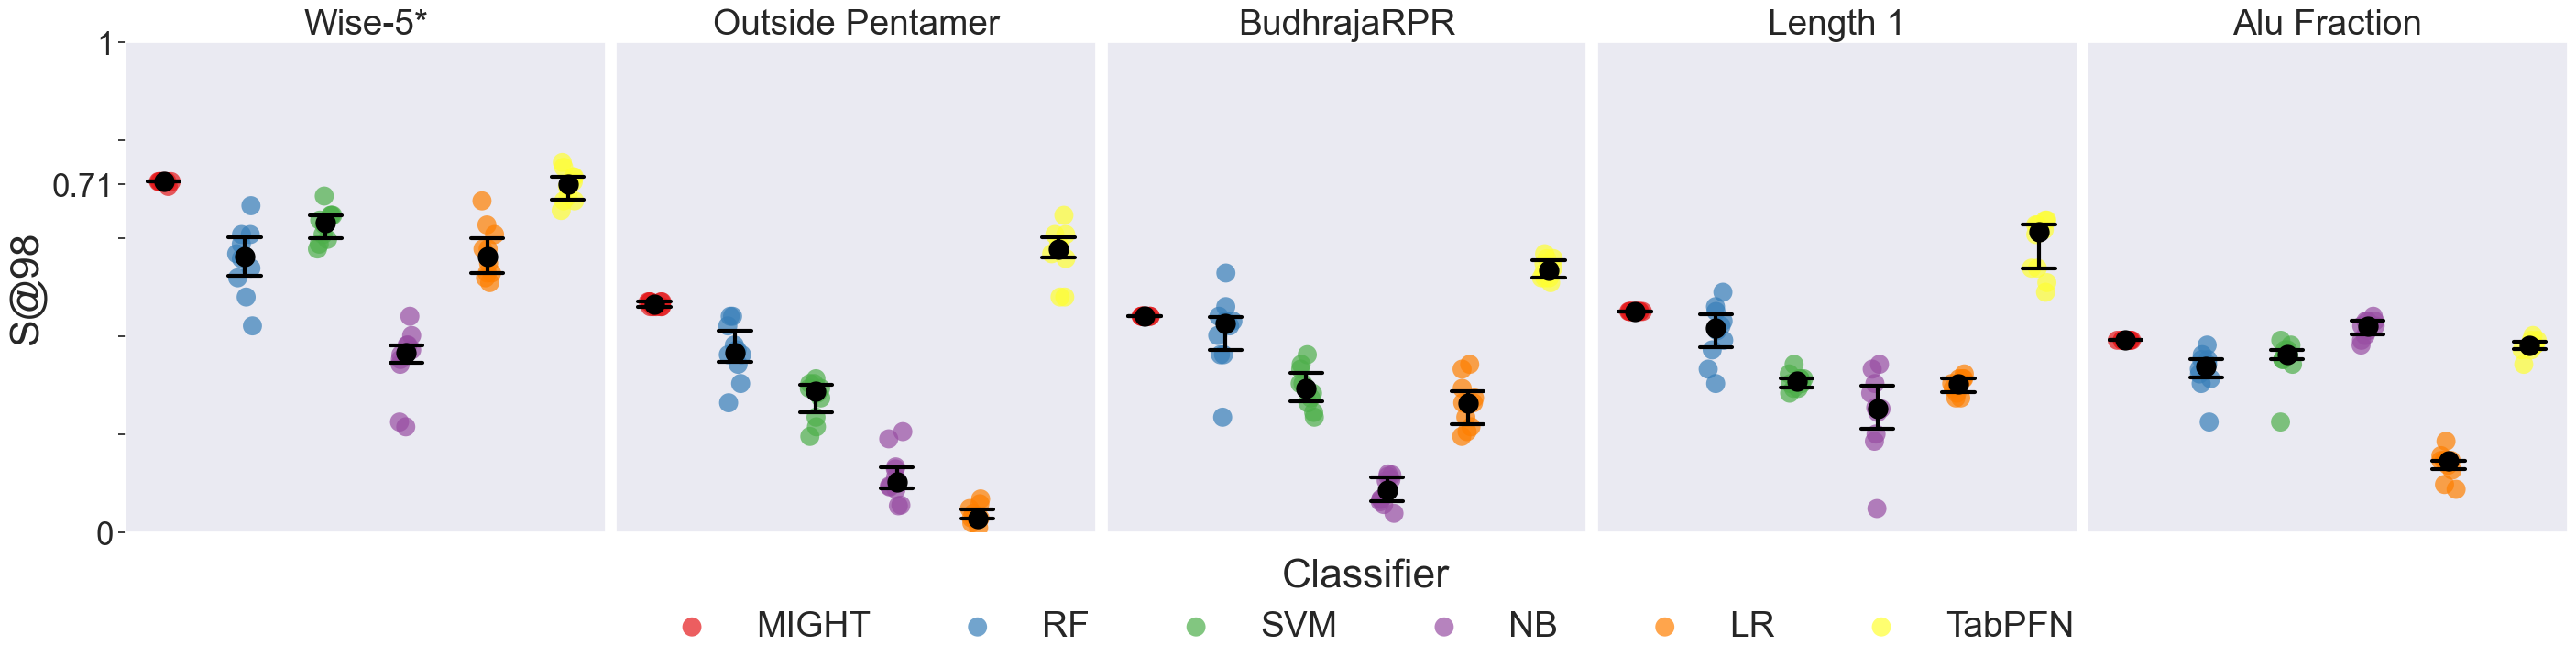

In [13]:
# sns.set_style(style='white')

FIG_DIR = "./figs_temp/"
# make separate plots for each classifier
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(28, 6), constrained_layout=True)
IQR_values = []
var_values = []
mean_values = []
new_type_diffs = type_diffs.copy()
new_type_diffs[4] = new_type_diffs[4] - 1
new_type_diffs[2] = new_type_diffs[2] - 3
new_type_diffs[3] = new_type_diffs[3] - 2
new_type_diffs[0] = new_type_diffs[0] + 1

top_features = np.array(features)[(type_lens + 0.5)[:-1].astype(int)]
for i, feature in enumerate(top_features):
    IQR_values.append([])
    var_values.append([])
    mean_values.append([])
    feature_data_per_run = df_per_run[df_per_run["Variable set"] == feature]
    sns.stripplot(
        x="Classifier",
        y="S@98",
        data=feature_data_per_run,
        jitter=True,
        size=15,
        order=clf_names,
        hue="Classifier",
        palette=palette_dict,
        alpha=0.7,
        ax=ax[i],
    )

    # add IQR lines for each feature
    for j, classifier in enumerate(clf_names):
        classifier_data = feature_data_per_run[
            feature_data_per_run["Classifier"] == classifier
        ]
        # get the 25th and 75th percentile
        q1 = classifier_data["S@98"].quantile(0.25)
        q3 = classifier_data["S@98"].quantile(0.75)

        # get the median
        median = classifier_data["S@98"].median()
        #         if j in type_lens[:-1] + 0.5 and j != 0:
        #             ax[i].axvline(x=j - 0.5, color="black", linestyle="--", alpha=0.3)

        # plot the IQR lines
        ax[i].plot([j - 0.2, j + 0.2], [q1, q1], color="black", linewidth=3, zorder=3)
        ax[i].plot([j - 0.2, j + 0.2], [q3, q3], color="black", linewidth=3, zorder=3)
        ax[i].plot([j, j], [q1, q3], color="black", linewidth=3, zorder=3)
        # plot the median,
        ax[i].plot(j, median, marker="o", color="black", zorder=3, markersize=15)
#         print(median)
    if i == 0:
        ax[i].set_yticks(
            [
                0,
                1,
                0.2,
                0.4,
                0.6,
                0.8,
                might_s98,
            ],
            ["0", "1", "", "", "", "", str(might_s98)],
        )
        ax[i].set_ylim([0, 1])
        ax[i].set_ylabel("S@98", fontsize=32)
    else:
        ax[i].set_ylim([0, 1])
        ax[i].set_yticks([])
        ax[i].set(ylabel=None)

    ax[i].set(xlabel=None)
    ax[i].tick_params(axis="y", labelsize=25)
    ax[i].set_xticks([])
    ax[i].set_title(f"{top_feature_titles[i]}", fontsize=28)
    ax[i].grid(False)
#     ax[i].set_facecolor("white")

fig.text(0.53, -0.06, "Classifier", ha="center", fontsize=32)
leg = fig.legend(
    clf_names,
    bbox_to_anchor=(0.53, -0.22),
    bbox_transform=plt.gcf().transFigure,
    ncol=6,
    loc="lower center",
    fontsize=28,
    frameon=False
)
leg.get_frame().set_linewidth(0.0)

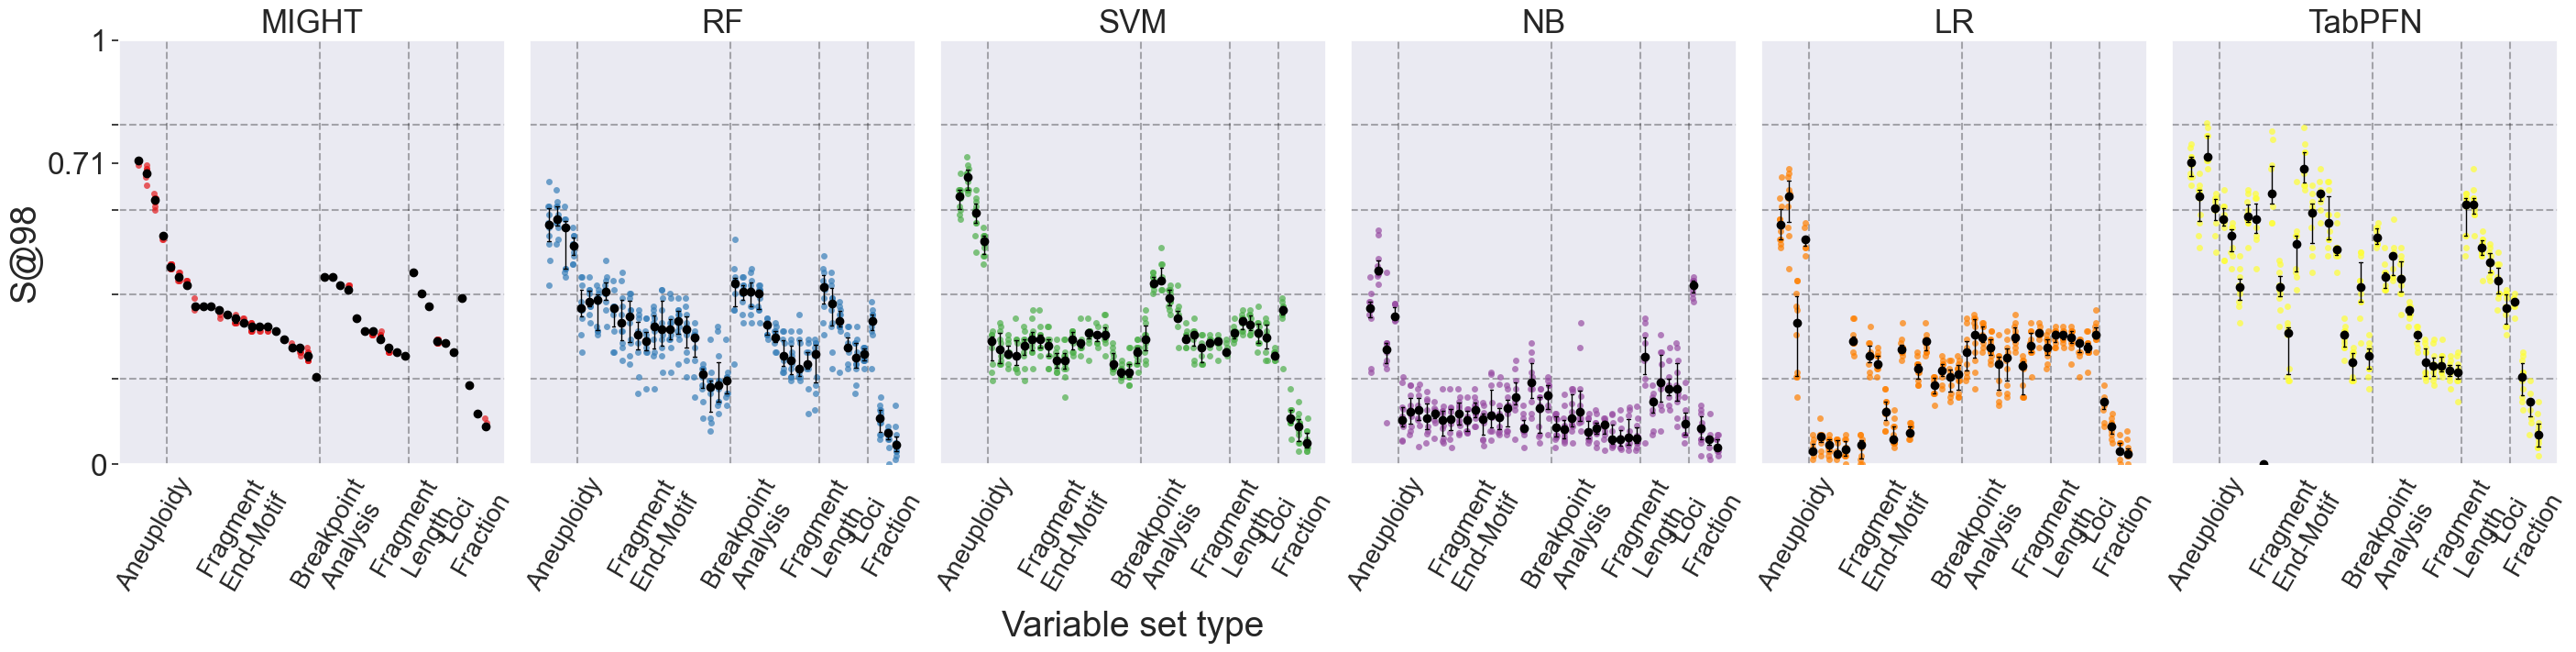

In [14]:
# set the style to Set1
sns.set_palette("Set1")
colors = sns.color_palette("Set1", n_colors=10, as_cmap=False)
# colors[1], colors[3] = colors[3], colors[1]

FIG_DIR = "./figs_temp/"
# make separate plots for each classifier
fig, ax = plt.subplots(nrows=1, ncols=6, figsize=(28, 7), constrained_layout=True)
IQR_values = []
var_values = []
mean_values = []
median_values = []
new_type_diffs = type_diffs.copy()
new_type_diffs[4] = new_type_diffs[4] - 1
new_type_diffs[2] = new_type_diffs[2] - 3
new_type_diffs[3] = new_type_diffs[3] - 2
new_type_diffs[0] = new_type_diffs[0] + 1

for i, classifier in enumerate(classifiers):
    IQR_values.append([])
    var_values.append([])
    mean_values.append([])
    median_values.append([])

    classifier_data_per_run = df_per_run[df_per_run["Classifier"] == classifier]
    sns.stripplot(
        x="Variable set",
        y="S@98",
        data=classifier_data_per_run,
        jitter=True,
        dodge=True,
        size=5,
        order=features,
        color=colors[i],
        alpha=0.7,
        ax=ax[i],
    )
    # add IQR lines for each feature
    for j, feature in enumerate(features):
        feature_data = classifier_data_per_run[
            classifier_data_per_run["Variable set"] == feature
        ]
        # get the 25th and 75th percentile
        q1 = feature_data["S@98"].quantile(0.25)
        q3 = feature_data["S@98"].quantile(0.75)

        IQR_values[i].append(q3 - q1)
        var_values[i].append(feature_data["S@98"].var())
        mean_values[i].append(feature_data["S@98"].mean())
        # get the median
        median = feature_data["S@98"].median()
        median_values[i].append(median)
        if j in type_lens[:-1] + 0.5 and j != 0:
            ax[i].axvline(x=j - 0.5, color="black", linestyle="--", alpha=0.3)

        # plot the IQR lines
        ax[i].plot([j - 0.2, j + 0.2], [q1, q1], color="black", linewidth=1, zorder=3)
        ax[i].plot([j - 0.2, j + 0.2], [q3, q3], color="black", linewidth=1, zorder=3)
        ax[i].plot([j, j], [q1, q3], color="black", linewidth=1, zorder=3)
        # plot the median,
        ax[i].plot(j, median, marker="o", color="black", zorder=3)
    # make the y-axis range from 0 to 1
    #     ax[i].set_xticks(type_lens, empty_labels, minor=False)
    ax[i].set_xticks([], [])
    ax[i].set_xticks(new_type_diffs, type_names, minor=True, fontsize=20)

    ax[i].tick_params(axis="x", which="minor", tick1On=False, tick2On=False)
    for tick in [0.2, 0.4, 0.6, 0.8]:
        ax[i].axhline(y=tick, color="black", linestyle="--", alpha=0.3)

    #     ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    for label in ax[i].get_xticklabels(which="minor"):
        label.set_horizontalalignment("center")
    if i != 2:
        ax[i].set(xlabel=None)
    else:
        ax[i].set_xlabel("Variable set type", fontsize=28)
    if i == 0:
        ax[i].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
        ax[i].set_yticks(
            [
                0,
                might_s98,
                1,
                0.2,
                0.4,
                0.6,
                0.8,
            ],
            ["0", str(might_s98), "1", "", "", "", ""],
        )
        ax[i].set_ylim([0, 1])
        ax[i].set_ylabel("S@98", fontsize=28)
    else:
        ax[i].set_ylim([0, 1])
        ax[i].set_yticks([])
        ax[i].set(ylabel=None)
    #     ax[i].set_yticks([0, 1])
    #     ax[i].xticks(rotation=90)
    #     ax[i].xlabel("Variable set", fontsize=15)
    #     ax[i].ylabel("sa98", fontsize=15)
    ax[i].set_title(f"{classifier}", fontsize=25)
    ax[i].tick_params(axis="x", which="minor", labelrotation=60, labelsize=20)
    ax[i].tick_params(axis="y", labelsize=24)
    ax[i].grid(False)


plt.savefig(FIG_DIR + f"cancer44_sa98_stripplot.pdf")
plt.show()

## Focus on MIGHT S@98

In [15]:
var_values = np.array(var_values)
IQR_values = np.array(IQR_values)
df_iqr_var = pd.DataFrame()
df_iqr_var["Classifier"] = np.concatenate(
    [[classifier] * len(features) for classifier in classifiers]
)
df_iqr_var["Mean"] = np.concatenate(mean_values)
df_iqr_var["IQR"] = np.concatenate(IQR_values)
df_iqr_var["Variance"] = np.concatenate(var_values)
df_iqr_var["Median"] = np.concatenate(median_values)
df_iqr_var["STD"] = np.sqrt(df_iqr_var["Variance"])

In [16]:
df_iqr_var["CoV"] = df_iqr_var["STD"] / df_iqr_var["Mean"]
df_iqr_var = df_iqr_var.round(7)

In [17]:
sns.set(font_scale=1.8)
# sns.set_theme(style='white')

# plt.rcParams['xtick.major.size'] = 20
plt.rcParams["xtick.major.width"] = 3
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True

In [18]:
def set_ticks(ax, ticks, minor=False):
    new_ticks = []
    new_tick_labels = []
    min_lim = ax.get_ylim()[0]
    max_lim = ax.get_ylim()[1]
    for tick in ax.get_yticks(minor=minor):
        if tick < min_lim or tick > max_lim:
            continue

        new_ticks.append(tick)
        if tick in ticks:
            if tick == 1:
                tick = int(tick)
            new_tick_labels.append(tick)
        else:
            new_tick_labels.append("")
    ax.set_yticks(new_ticks, new_tick_labels, minor=minor, fontsize=24)
    ax.set_ylim([min_lim, max_lim])

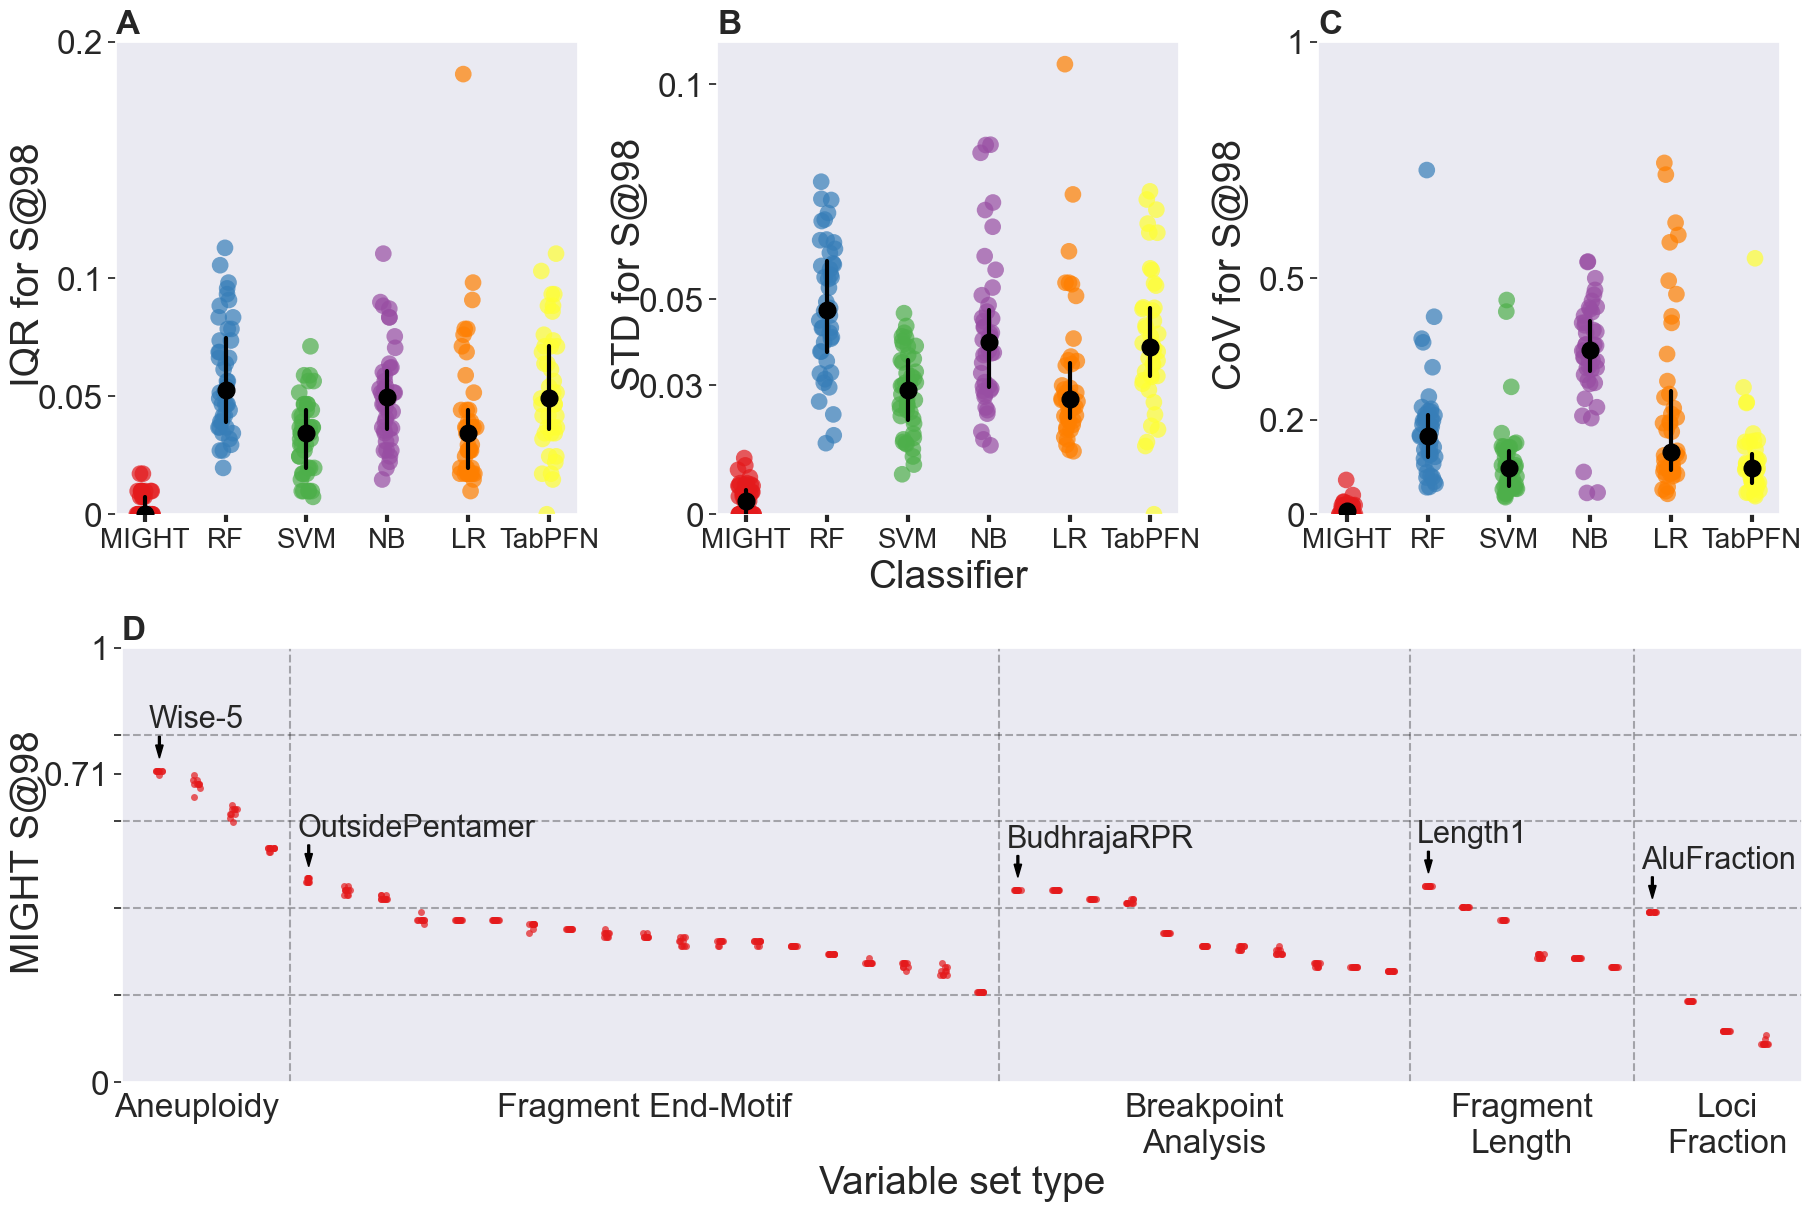

In [19]:
min_digit = [3, 3, 2]
linear_ticks = [[0, 0.05, 0.1, 0.2], [0, 0.03, 0.05, 0.1], [0, 0.2, 0.5, 1]]
log_ticks = [[0.01, 0.1], [0.01, 0.1], [0.01, 0.1]]
fig = plt.figure(figsize=(18, 12), constrained_layout=True)
subfigs = fig.subfigures(nrows=2, ncols=1, height_ratios=[1, 1])
type_names = [
    "Aneuploidy",
    "Fragment End-Motif",
    "Breakpoint\nAnalysis",
    "Fragment\nLength",
    "Loci\nFraction",
]

ax = subfigs[1].subplots(nrows=1, ncols=1)
plt.subplots_adjust(left=0.1, right=0.1, bottom=0.1, top=0.9, wspace=0.2, hspace=0.4)

for i, classifier in enumerate(classifiers):
    if i > 0:
        continue

    classifier_data_per_run = df_per_run[df_per_run["Classifier"] == classifier]
    sns.stripplot(
        x="Variable set",
        y="S@98",
        data=classifier_data_per_run,
        jitter=0.1,
        dodge=True,
        size=5,
        order=features,
        color=colors[i],
        alpha=0.7,
        ax=ax,
    )
    # add IQR lines for each feature
    for j, feature in enumerate(features):
        feature_data = classifier_data_per_run[
            classifier_data_per_run["Variable set"] == feature
        ]
        # get the 25th and 75th percentile
        q1 = feature_data["S@98"].quantile(0.25)
        q3 = feature_data["S@98"].quantile(0.75)

        # get the median
        median = feature_data["S@98"].median()
        if j in type_lens[:-1] + 0.5:
            ax.annotate(feature.split(".")[1], (j - 0.3, median + 0.1), fontsize=22)
            ax.arrow(
                j,
                median + 0.08,
                0,
                -0.02,
                color="black",
                length_includes_head=False,
                width=0.05,
                head_width=0.2,
                head_length=0.03,
            )
            if j != 0:
                ax.axvline(x=j - 0.5, color="black", linestyle="--", alpha=0.3)
    # make the y-axis range from 0 to 1
    ax.set_xticks([], [])
    ax.set_xticks(type_diffs, type_names, minor=True, fontsize=24)
    for tick in [0.2, 0.4, 0.6, 0.8]:
        ax.axhline(y=tick, color="black", linestyle="--", alpha=0.3)

    ax.tick_params(axis="x", which="minor", tick1On=False, tick2On=False)
    for label in ax.get_xticklabels(which="minor"):
        label.set_horizontalalignment("center")

    ax.set_xlabel("Variable set type", fontsize=28)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.set_yticks(
        [0, might_s98, 1, 0.2, 0.4, 0.6, 0.8],
        ["0", str(might_s98), "1", "", "", "", ""],
    )
    ax.set_ylim([0, 1])
    ax.set_xlim([-1, len(features)])
    ax.set_ylabel("MIGHT S@98", fontsize=28)
    ax.yaxis.set_label_coords(-0.045, 0.53)

    #     ax.tick_params(axis="x", which="minor", labelrotation=45)
    ax.grid(False)
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=24)

ax.set_title(string.ascii_uppercase[3], loc="left", weight="bold", fontsize=24)

ax = subfigs[0].subplots(nrows=1, ncols=3)
metrics = ["IQR", "STD", "CoV"]
for i in range(3):
    sns.stripplot(
        x="Classifier",
        y=metrics[i],
        data=df_iqr_var,
        jitter=True,
        size=12,
        hue="Classifier",
        alpha=0.7,
        ax=ax[i],
        dodge=False,
        palette=colors,
    )
    for j, clf in enumerate(clf_names):
        q1 = df_iqr_var[df_iqr_var["Classifier"] == clf][metrics[i]].quantile(0.25)
        q3 = df_iqr_var[df_iqr_var["Classifier"] == clf][metrics[i]].quantile(0.75)

        # get the median
        median = df_iqr_var[df_iqr_var["Classifier"] == clf][metrics[i]].median()
        # plot the IQR lines
        ax[i].plot([j, j], [q1, q3], color="black", linewidth=3, zorder=3)
        # plot the median,
        ax[i].plot(j, median, marker="o", color="black", markersize=12, zorder=3)

    ax[i].set_ylabel(metrics[i] + " for S@98", fontsize=28)
    ax[i].yaxis.set_label_coords(-0.15, 0.53)
#     ax[i].set_yscale("log")

    formatr = FormatStrFormatter("%.2f")
    ax[i].get_yaxis().set_major_formatter(formatr)

    #     set_ticks(ax[i], log_ticks[i], False)
    #     set_ticks(ax[i], log_ticks[i], True)
    ax[i].set_yticks(linear_ticks[i], [str(linear_tick) for linear_tick in linear_ticks[i]])
#     ax[i].set_yticks(log_ticks[i], [str(log_tick) for log_tick in log_ticks[i]])

    if i != 1:
        ax[i].set(xlabel=None)
    else:
        ax[i].set_xlabel("Classifier", fontsize=28)
    ax[i].legend([], [], frameon=False)
    ax[i].tick_params(axis="x", labelsize=20)
    ax[i].tick_params(axis="y", labelsize=24)
    ax[i].grid(False)
    ax[i].set_ylim(0)

    ax[i].set_title(string.ascii_uppercase[i], loc="left", weight="bold", fontsize=24)

fig.align_ylabels()
plt.savefig(FIG_DIR + f"cancer44_sa98_plus_three_stripplot.pdf")
plt.show()

In [20]:
clf_dict = {
    "RF": 1,
    "SVM":2,
    "NB": 3,
    "LR": 0,
    "MIGHT": 4,
}
df_medians = (
    df_per_run.groupby(["Classifier", "Variable set"])["S@98"]
    .median()
    .to_frame()
    .sort_values(["S@98", "Classifier"], key=lambda x: x.map(clf_dict))
)
might_s98_median = df_iqr_var[df_iqr_var["Classifier"] == "MIGHT"]["Median"].max()

In [21]:
def sa98_median_by_variable(ax, letter):

    ax.set_title(string.ascii_uppercase[letter], loc="left", weight="bold", fontsize=24)
    sns.stripplot(
        x="Variable set",
        y="S@98",
        data=df_medians,
        jitter=False,
#         dodge=True,
        size=12,
        order=features,
        hue="Classifier",
        hue_order=clf_names,
        alpha=0.7,
        palette=palette_dict,
        ax=ax,
    )
    ax.set_xticks([], [])
    # ax.set_xticks(new_type_diffs, type_names, minor=True, fontsize=24)
    ax.set_xticks(type_diffs, type_names, minor=True, fontsize=24)

    ax.tick_params(axis="x", which="minor", tick1On=False, tick2On=False)

    #     ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    for label in ax.get_xticklabels(which="minor"):
        label.set_horizontalalignment("center")
    ax.set_xlabel("Variable set type", fontsize=28)
    ax.set_ylim([0, 1])
    ax.tick_params(axis="y", labelsize=24)
    ax.set_ylabel("S@98", fontsize=28)
    # ax.set_title("Classifier m", fontsize=40)
    ax.set_yticks(
        [might_s98_median, 0, 1],
        [
            str(round(might_s98_median, 2)),
            "0",
            "1",
        ],
    )
    ax.yaxis.set_label_coords(-0.045, 0.53)
    ax.get_yticklabels()[0].set_fontweight("bold")
    ax.get_yticklabels()[0].set_style('italic')
    ax.get_yticklabels()[0].set_color("red")

    # ax.margins(x=0.01)
    ax.set_xlim([-1, len(features)])
    ax.grid(False)
    ax.get_legend().remove()

    for tick in [0.2, 0.4, 0.6, 0.8]:
        ax.axhline(y=tick, color="black", linestyle="--", alpha=0.3)
    for j, feature in enumerate(features):
        feature_data = classifier_data_per_run[
            classifier_data_per_run["Variable set"] == feature
        ]
        # get the 25th and 75th percentile
        q1 = feature_data["S@98"].quantile(0.25)
        q3 = feature_data["S@98"].quantile(0.75)

        # get the median
        median = feature_data["S@98"].median()
        if j in type_lens[:-1] + 0.5:
            feature_name = feature.split(".")[1]
            if feature_name == "Wise-5":
                ax.plot(
                    j,
                    median + 0.2,
                    marker="*",
                    markersize=20,
                    color="black",
                )
            ax.annotate(feature_name, (j - 0.3, median + 0.1), fontsize=22)
            ax.arrow(
                j,
                median + 0.08,
                0,
                -0.02,
                color="black",
                length_includes_head=False,
                width=0.05,
                head_width=0.2,
                head_length=0.03,
            )
            if j != 0:
                ax.axvline(x=j - 0.5, color="black", linestyle="--", alpha=0.3)

In [279]:
def sa98_median_by_iqr(ax, letter=None, yaxis="log", ytype="Median"):
    if letter != None:
        ax.set_title(
            string.ascii_uppercase[letter], loc="left", weight="bold", fontsize=24
        )
    df_temp = round(df_iqr_var, 3)
    df_temp["IQR"] = df_temp["IQR"].clip(lower=1 / 102)
    sns.scatterplot(
        x="CoV",
        y=ytype,
        data=df_temp.sort_values([ytype, "Classifier"], key=lambda x: x.map(clf_dict)),
        s=150,
        hue="Classifier",
        hue_order=clf_names,
        alpha=0.7,
        palette=palette_dict,
        style="Variable-Set Type",
        edgecolor="grey",
        ax=ax,
    )

    for pos in [0.01, 0.1]:
        ax.axvline(x=pos, color="black", linestyle="--", alpha=0.3)
    # ax.axvline(x=1 / 102, color="black", linestyle="-", alpha=1)
    ax.axhline(y=0.4, color="black", linestyle="--", alpha=0.3)
    # ax.axhline(y=might_s98_median, color="black", linestyle="-", alpha=1)

    #     ax.set_xlim([0.0095, 0.195])
    ax.set_xscale("log")
    ax.set_xticks(
        [
            round(df_iqr_var.iloc[0]["CoV"], 3),
            0.01,
            0.1,
            round(df_iqr_var.iloc[220]["CoV"], 3),
        ],
        [
            str(round(df_iqr_var.iloc[0]["CoV"], 3)),
            str(0.01),
            str(0.1),
            str(round(df_iqr_var.iloc[220]["CoV"], 3)),
        ],
    )
    #     ax.tick_params(axis="x", which="minor", tick1On=False, tick2On=False)
    ax.tick_params(axis="x", labelsize=24)
    ax.get_xticklabels()[0].set_fontweight("bold")
    ax.get_xticklabels()[0].set_style("italic")
    ax.get_xticklabels()[0].set_color("red")

    ax.margins(x=0.01)
    ax.set_xlabel("CoV", fontsize=28)

    ax.set_ylim([0.02, 1])
    if yaxis == "log":
        ax.set_yscale("log")
    ax.set_yticks(
        [might_s98_median, 0.02, 0.2, 0.1, 0.4],
        [str(round(might_s98_median, 2)), str(0.02), str(0.2), "", str(0.4)],
    )
    ax.get_yticklabels()[0].set_fontweight("bold")
    ax.get_yticklabels()[0].set_style("italic")
    ax.get_yticklabels()[0].set_color("red")
    #     ax.tick_params(axis="y", which="minor", tick1On=False, tick2On=False)
    ax.tick_params(axis="y", labelsize=24)
    ax.set_ylabel(ytype, fontsize=28)

    ax.grid(False)
    ax.get_legend().remove()
    ax.set_title("Reliability of S@98 across multiple replications", fontsize=28)

In [79]:
def sa98_multi_metrics(ax, letter=0, metrics=["IQR", "STD", "CoV"]):
    for i in range(len(metrics)):
        sns.stripplot(
            x="Classifier",
            y=metrics[i],
            data=df_iqr_var,
            jitter=True,
            size=12,
            hue="Classifier",
            alpha=0.7,
            ax=ax[i],
            dodge=False,
            palette=colors,
        )
        for j, clf in enumerate(clf_names):
            q1 = df_iqr_var[df_iqr_var["Classifier"] == clf][metrics[i]].quantile(0.25)
            q3 = df_iqr_var[df_iqr_var["Classifier"] == clf][metrics[i]].quantile(0.75)

            # get the median
            median = df_iqr_var[df_iqr_var["Classifier"] == clf][metrics[i]].median()
            # plot the IQR lines
            ax[i].plot([j, j], [q1, q3], color="black", linewidth=3, zorder=3)
            # plot the median,
            ax[i].plot(j, median, marker="o", color="black", markersize=12, zorder=3)

            if clf == "MIGHT":
                might_median = round(median, 3)
                if might_median == 0:
                    might_median = int(might_median)

        ax[i].set_ylabel(metrics[i] + " for S@98", fontsize=28)
        ax[i].yaxis.set_label_coords(-0.15, 0.53)
        #     ax[i].set_yscale("log")

        formatr = FormatStrFormatter("%.2f")
        ax[i].get_yaxis().set_major_formatter(formatr)

        #     set_ticks(ax[i], log_ticks[i], False)
        #     set_ticks(ax[i], log_ticks[i], True)
        ax[i].set_yticks(
            linear_ticks[i][1:] + [might_median],
            [str(linear_tick) for linear_tick in linear_ticks[i][1:] + [might_median]],
        )
        ax[i].get_yticklabels()[-1].set_fontweight("bold")
        ax[i].get_yticklabels()[-1].set_style('italic')
        ax[i].get_yticklabels()[-1].set_color("red")
        #     ax[i].set_yticks(log_ticks[i], [str(log_tick) for log_tick in log_ticks[i]])

        #         ax[i].set(xlabel=None)
        if i != 1:
            ax[i].set(xlabel=None)
        else:
            ax[i].set_xlabel("Classifier", fontsize=28)
        ax[i].legend([], [], frameon=False)
        ax[i].tick_params(axis="x", labelsize=20)
        ax[i].tick_params(axis="y", labelsize=24)
        ax[i].grid(False)
        ax[i].set_ylim(0)

        ax[i].set_xticks([], [])
        ax[i].set_title(
            string.ascii_uppercase[i + letter], loc="left", weight="bold", fontsize=24
        )

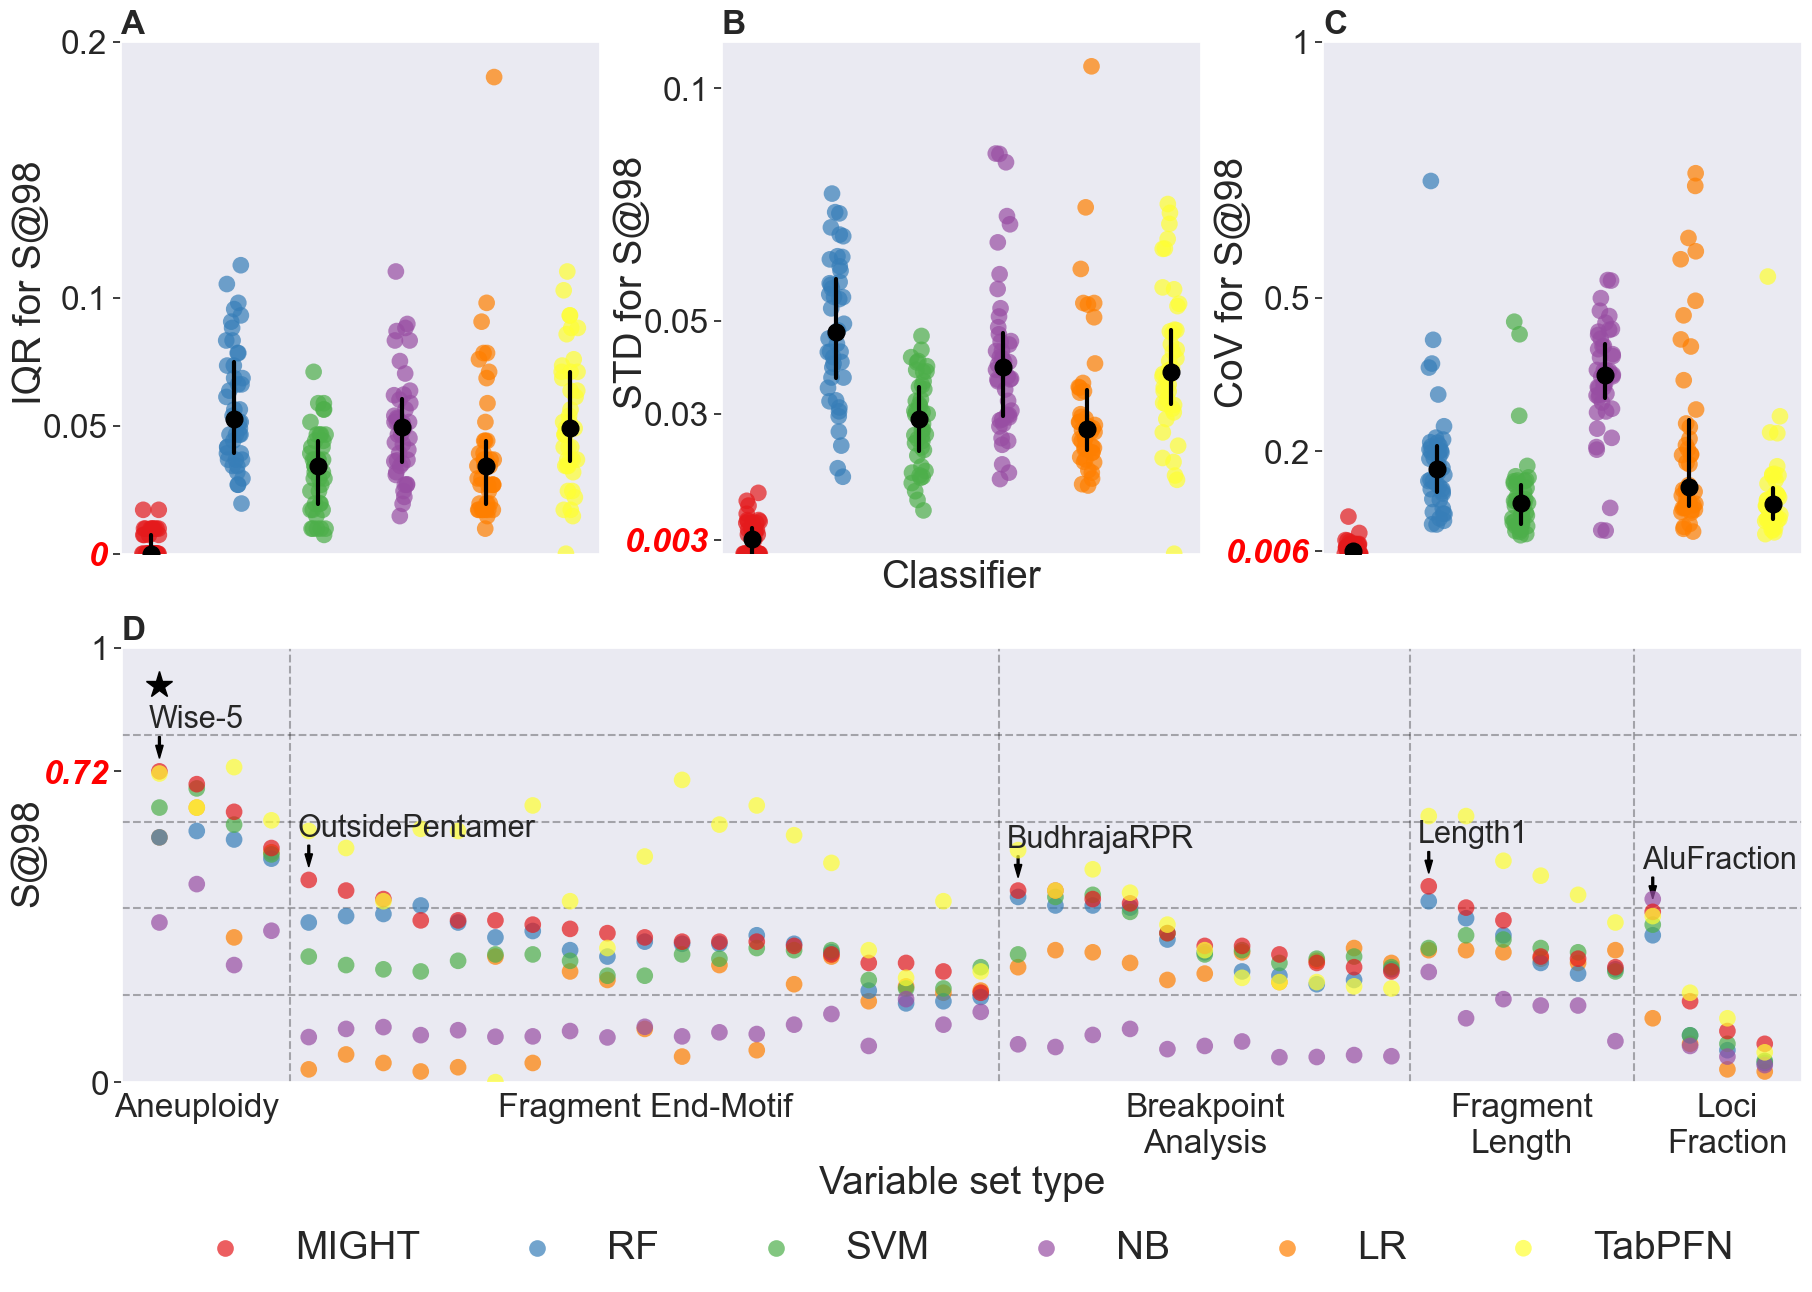

In [147]:
min_digit = [3, 3, 2]
linear_ticks = [[0, 0.05, 0.1, 0.2], [0, 0.03, 0.05, 0.1], [0, 0.2, 0.5, 1]]
log_ticks = [[0.01, 0.1], [0.01, 0.1], [0.01, 0.1]]
fig = plt.figure(figsize=(18, 12), constrained_layout=True)
subfigs = fig.subfigures(nrows=2, ncols=1, height_ratios=[1, 1])
type_names = [
    "Aneuploidy",
    "Fragment End-Motif",
    "Breakpoint\nAnalysis",
    "Fragment\nLength",
    "Loci\nFraction",
]

# ax = subfigs[0].subplots(nrows=1, ncols=1)
ax = subfigs[0].subplots(nrows=1, ncols=3)
letter = 0
# plt.subplots_adjust(left=0.1, right=0.1, bottom=0.1, top=0.9, wspace=0.2, hspace=0.4)

# sa98_median_by_variable(ax, letter)
sa98_multi_metrics(ax, letter)

ax = subfigs[1].subplots(nrows=1, ncols=1)
letter = 3
# sa98_median_by_iqr(ax, letter)
sa98_median_by_variable(ax, letter)


fig.align_ylabels()
leg = subfigs[0].legend(
    clf_names,
    bbox_to_anchor=(0.53, -0.08),
    bbox_transform=plt.gcf().transFigure,
    ncol=6,
    loc="lower center",
    fontsize=28,
    frameon=False,
)
for i in range(5):
    leg.legend_handles[i].set_facecolor(colors[i])

leg.get_frame().set_linewidth(0.0)
# plt.savefig(FIG_DIR + f"figure_2_real_sa98.pdf")
plt.show()

In [277]:
type_sizes = [4, 19, 11, 6, 4]
marker_styles = {
    "Aneuploidy": "o",
    "Fragment\nEnd-Motif": "^",
    "Breakpoint\nAnalysis": "s",
    "Fragment\nLength": "*",
    "Loci\nFraction": "D",
}

In [247]:
type_names = [
    "Aneuploidy",
    "Fragment End-Motif",
    "Breakpoint\nAnalysis",
    "Fragment\nLength",
    "Loci\nFraction",
]
type_sizes = [4, 19, 11, 6, 4]
marker_column = np.array([])
for i in range(len(clf_names)):
    for j,type_size in enumerate(type_sizes):
        marker_column = np.concatenate((marker_column, type_size*[type_names[j]]))
        
df_iqr_var["Variable-Set Type"] = marker_column

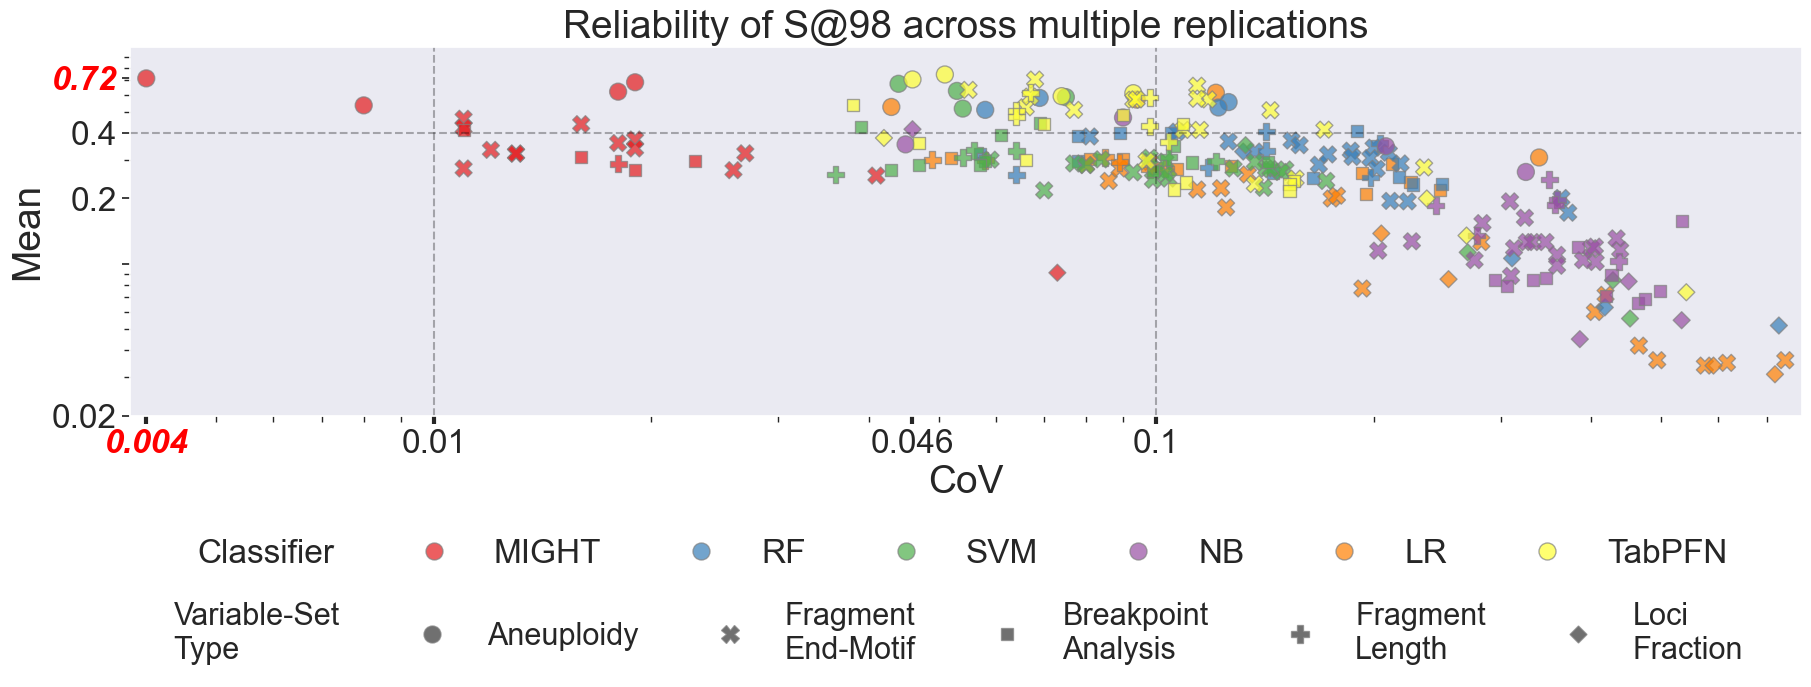

In [280]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6), constrained_layout=True)


sa98_median_by_iqr(ax, yaxis="log", ytype="Mean")
# fig.align_ylabels()


handles, labels = ax.get_legend_handles_labels()


hue_labels = df_iqr_var["Classifier"].dropna().unique()
style_labels = df_iqr_var["Variable-Set Type"].dropna().unique()

hue_handles = handles[: len(hue_labels)+1]
hue_names = labels[: len(hue_labels)+1]

style_handles = handles[len(hue_labels) +1:]
style_names = labels[len(hue_labels) +1:]
style_names[0] = "Variable-Set\nType"

legend1 = ax.legend(
    handles=hue_handles,
    labels=hue_names,
    loc="lower center",
    bbox_to_anchor=(0.47, -0.5),
    frameon=False,
#     mode='expand', 
#     borderaxespad=0.,
    ncol=len(hue_handles),
    fontsize=24,
)

# Second legend (sex/style)
legend2 = ax.legend(
    handles=style_handles,
    labels=style_names,  # title='Variable-Set Type',
    loc="lower center",
    bbox_to_anchor=(0.47, -0.75),
    frameon=False,
#     mode='expand', borderaxespad=0.,
    ncol=len(style_handles),
    fontsize=22,
)

# Add back the first legend manually
ax.add_artist(legend1)

